In [1]:
from ai4wc.models.nuViT import test_patchify

ModuleNotFoundError: No module named 'ai4wc'

In [2]:
path_to_img = 'event.png'

torch.Size([1, 4, 500, 500])
torch.Size([4, 10, 10, 50, 50])


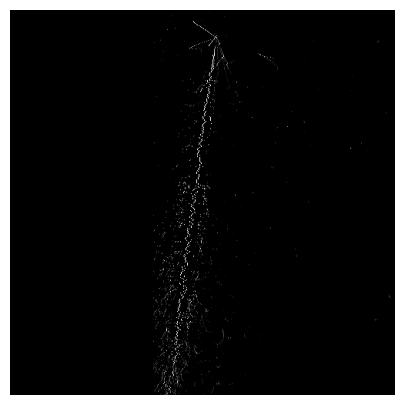

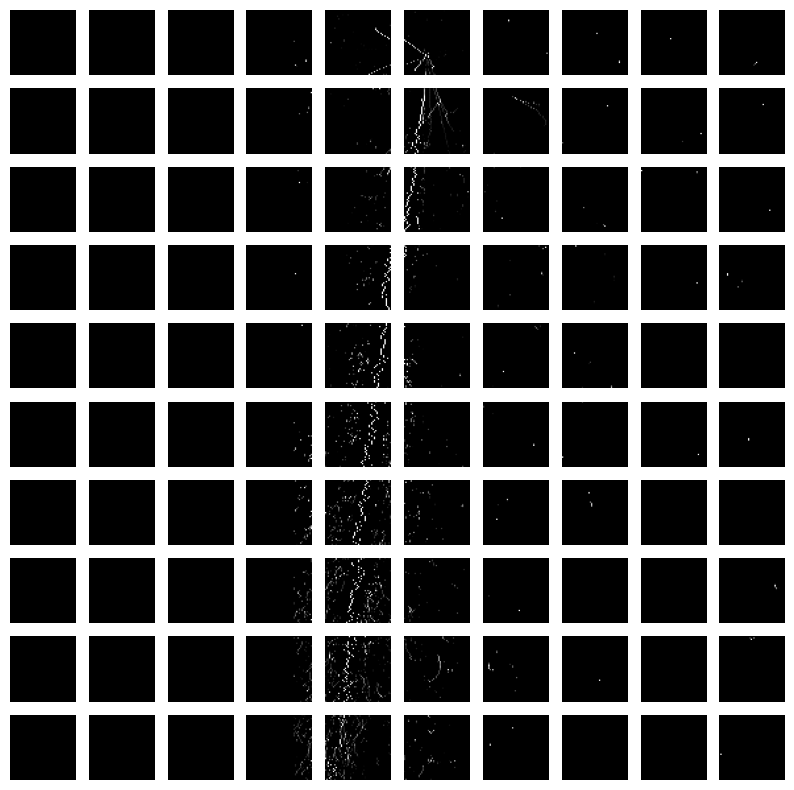

In [3]:
test_patchify(path_to_image=path_to_img, patch_size=(50,50), image_size=(500,500))

## Test of the training

In [ ]:
## Data loader
from torch.utils.data import Dataset, DataLoader
import os
from glob import glob
import numpy as np
import zlib
from PIL import Image
from ai4wc.models.nuViT import nuViT

class CVNDataset(Dataset):
    def __init__(self, root):
        self.root = root
        self.plane = None
        self.entries = []
        self.cand_flavs = ['numu', 'nue', 'nc']
        for flav in self.cand_flavs:
            d = os.path.join(root, flav)
            if not os.path.isdir(d):
                continue
            for gz in sorted(glob(os.path.join(d, "event*.gz"))):
                key = os.path.splitext(os.path.basename(gz))[0].replace("event", "")
                self.entries.append((flav, key, gz))
    
    def classes(self):
        return self.cand_flavs
    
    def __len__(self):
        return len(self.entries)
    
    def _read_array(self, gz_path):
        with open(gz_path, 'rb') as f:
            arr = np.frombuffer(bytearray(zlib.decompress(f.read())), dtype=np.uint8).reshape(3, 500, 500)
        return arr
    
    def _to_pil(self, arr3):
        idx_map = {"U": 0, "V": 1, "Z": 2, "0": 0, "1": 1, "2": 2}
        _plane = "Z"
        idx = idx_map[_plane]
        plane = arr3[idx]
        img = np.repeat(plane[..., None], 3, axis=2)
        return Image.fromarray(img, mode='RGB')

    def get_eventinfo(self, info_path):
        path = info_path
        ret = {}
        with open(path, 'rb') as info_file:
            info = info_file.readlines()
            ret['NuPDG'] = int(info[7].strip())
            ret['NuEnergy'] = float(info[1])
            ret['LepEnergy'] = float(info[2])
            ret['Interaction'] = int(info[0].strip()) % 4
            ret['NProton'] = int(info[8].strip())
            ret['NPion'] = int(info[9].strip())
            ret['NPiZero'] = int(info[10].strip())
            ret['NNeutron'] = int(info[11].strip())
            #ret['OscWeight'] = float(info[6])
        return ret
    
    def __getitem__(self, idx):
        _, _, gz = self.entries[idx]
        arr = self._read_array(gz)
        img = self._to_pil(arr)
        # target = 0  # dummy label for SSL
        target = self.get_eventinfo(gz.replace('.gz', '.info'))
        if self.transform is not None:
            img = self.transform(img)
        if self.target_transform is not None:
            target = self.target_transform(target)
        # print(f"TARGET VALUE : {target}")
        ## Try to predict flavor first. Later we can try to predict other things from the info file.        
        # target = self.cand_flavs.index(self.entries[idx][0])  # convert flavor to index
        # print(f'type(target) : {type(target)}')
        ##
        ## Try to predict the NuPDG
        # target = self.pdgs.index(target['NuPDG'])  # convert NuPDG to index

        if target['NuPDG'] in [14, -14]:   # numuCC
            target = 0
        elif target['NuPDG'] in [12, -12]: # nueCC
            target = 1
        else:                              # NC
            target = 2
        return img, target

: 

In [5]:
path_to_train = 'data_cvn/train'
path_to_val = 'data_cvn/val'
path_to_test = 'data_cvn/test'

train_dataset = CVNDataset(root=path_to_train)
val_dataset = CVNDataset(root=path_to_val)
test_dataset = CVNDataset(root=path_to_test)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

In [ ]:
model = nuViT(
    
)